In [1]:
%pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.9 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if len(files) > 0:
        print(root)
        print(files[:10])
        print("-" * 60)

/kaggle/input/datasets/raghavnanjappan/weapon-dataset-for-yolov5
['dataset.yaml']
------------------------------------------------------------
/kaggle/input/datasets/raghavnanjappan/weapon-dataset-for-yolov5/dataset/dataset/labels
['val.cache', 'train.cache']
------------------------------------------------------------
/kaggle/input/datasets/raghavnanjappan/weapon-dataset-for-yolov5/dataset/dataset/labels/val
['4099.txt', '4146.txt', '2070.txt', '2013.txt', '4093.txt', '4136.txt', '4117.txt', '4102.txt', '4133.txt', '4151.txt']
------------------------------------------------------------
/kaggle/input/datasets/raghavnanjappan/weapon-dataset-for-yolov5/dataset/dataset/labels/train
['1893.txt', '1711.txt', '3504.txt', '1773.txt', '559.txt', '1812.txt', '1093.txt', '1356.txt', '2869.txt', '3926.txt']
------------------------------------------------------------
/kaggle/input/datasets/raghavnanjappan/weapon-dataset-for-yolov5/dataset/dataset/images/val
['2008.jpg', '4125.jpg', '2029.jpg', '

In [3]:
with open("/kaggle/input/datasets/raghavnanjappan/weapon-dataset-for-yolov5/dataset.yaml", "r") as f:
    print(f.read())

# Path to the dataset
path: ../dataset  # dataset root dir
train: images/train  # train images (relative to 'path') 4000 images
val: images/val  # val images (relative to 'path') 156 images
test:  # test images (optional)

# Classes
names:
  0: Knife
  1: Handgun



In [4]:
import os

base_path = "/kaggle/input/datasets/raghavnanjappan/weapon-dataset-for-yolov5/dataset/dataset"

print("Train images exists:", os.path.exists(os.path.join(base_path, "images/train")))
print("Val images exists:", os.path.exists(os.path.join(base_path, "images/val")))
print("Train labels exists:", os.path.exists(os.path.join(base_path, "labels/train")))
print("Val labels exists:", os.path.exists(os.path.join(base_path, "labels/val")))

new_yaml = f"""
path: {base_path}
train: images/train
val: images/val

names:
  0: Knife
  1: Handgun
"""

with open("/kaggle/working/weapon_data.yaml", "w") as f:
    f.write(new_yaml)

print("\nNew YAML file created:\n")
print(open("/kaggle/working/weapon_data.yaml", "r").read())

Train images exists: True
Val images exists: True
Train labels exists: True
Val labels exists: True

New YAML file created:


path: /kaggle/input/datasets/raghavnanjappan/weapon-dataset-for-yolov5/dataset/dataset
train: images/train
val: images/val

names:
  0: Knife
  1: Handgun



In [5]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

results = model.train(
    data="/kaggle/working/weapon_data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="/kaggle/working",
    name="weapon_detection_yolov8s"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/weapon_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,

In [2]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for f in files:
        if f in ["best.pt", "last.pt", "results.csv"]:
            print(os.path.join(root, f))

In [4]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f in ["best.pt", "last.pt", "results.csv"]:
            print(os.path.join(root, f))

/kaggle/input/notebooks/sibtainabbas1965/notebookaca5840b38/weapon_detection_yolov8s/results.csv
/kaggle/input/notebooks/sibtainabbas1965/notebookaca5840b38/weapon_detection_yolov8s/weights/last.pt
/kaggle/input/notebooks/sibtainabbas1965/notebookaca5840b38/weapon_detection_yolov8s/weights/best.pt


In [1]:
import os, pkgutil, subprocess, sys

# 1) Ultralytics install agar current session mein missing ho
if pkgutil.find_loader("ultralytics") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])

from ultralytics import YOLO

# 2) Best model ka path (saved notebook output se)
best_model_path = "/kaggle/input/notebooks/sibtainabbas1965/notebookaca5840b38/weapon_detection_yolov8s/weights/best.pt"

# 3) Corrected YAML dobara banao (new session ke liye)
base_path = "/kaggle/input/datasets/raghavnanjappan/weapon-dataset-for-yolov5/dataset/dataset"

yaml_text = f"""
path: {base_path}
train: images/train
val: images/val

names:
  0: Knife
  1: Handgun
"""

yaml_path = "/kaggle/working/weapon_data.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_text)

print("YAML saved at:", yaml_path)
print(open(yaml_path, "r").read())

# 4) Model load karo
model = YOLO(best_model_path)

# 5) Validation / evaluation chalao
metrics = model.val(
    data=yaml_path,
    split="val",
    imgsz=640,
    batch=16,
    conf=0.001
)

# 6) Main metrics print karo
print("\n===== VALIDATION RESULTS =====")
print("mAP50      :", metrics.box.map50)
print("mAP50-95   :", metrics.box.map)
print("Precision  :", metrics.box.mp)
print("Recall     :", metrics.box.mr)

/tmp/ipykernel_55/2104215598.py:4: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("ultralytics") is None:


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YAML saved at: /kaggle/working/weapon_data.yaml

path: /kaggle/input/datasets/raghavnanjappan/weapon-dataset-for-yolov5/dataset/dataset
train: images/train
val: images/val

names:
  0: Knife
  1: Handgun

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6.7±3.5 MB/s, size: 52.3 KB)
val: Scanning /kaggle/input/datasets/raghavnanjappan/weapon-dataset-for-yolov5/dataset/dataset/labels/val... 156 images, 0 backgrounds, 0 corrupt: 100% 

Files in validation folder:
['val_batch1_labels.jpg', 'BoxP_curve.png', 'BoxF1_curve.png', 'val_batch2_pred.jpg', 'confusion_matrix.png', 'val_batch0_labels.jpg', 'val_batch1_pred.jpg', 'BoxR_curve.png', 'confusion_matrix_normalized.png', 'val_batch2_labels.jpg', 'val_batch0_pred.jpg', 'BoxPR_curve.png']

Showing: confusion_matrix.png


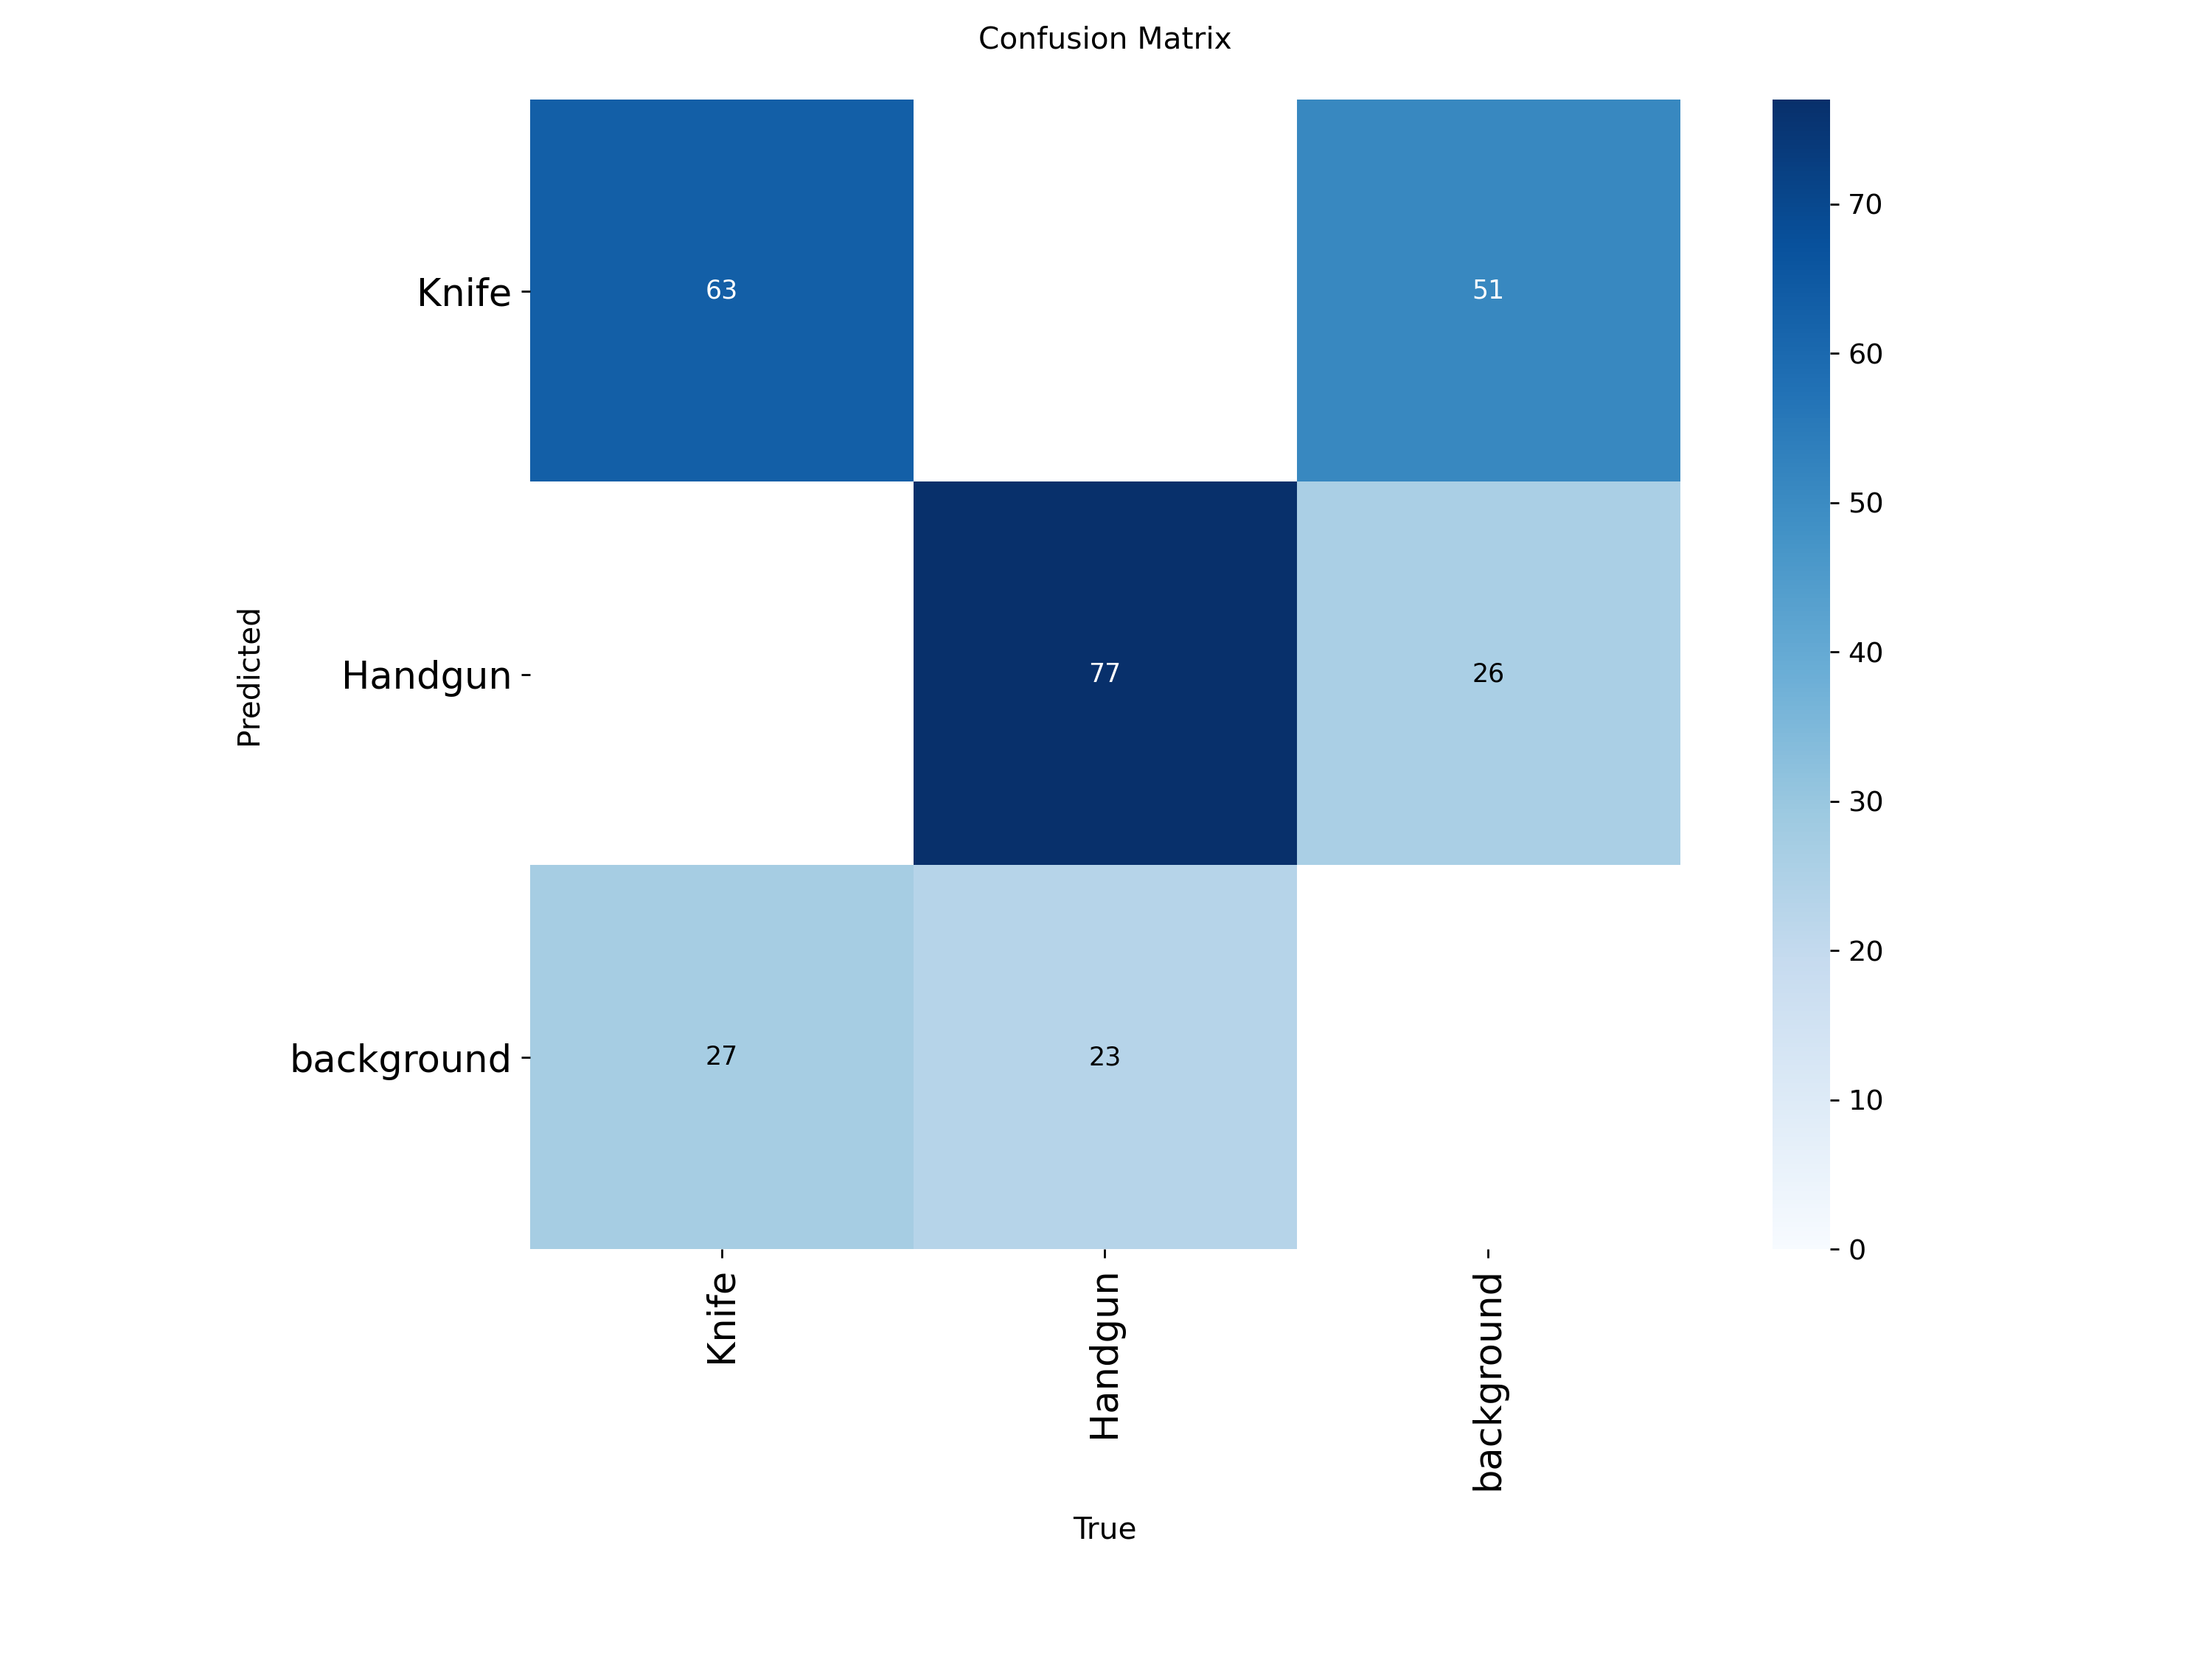


Showing: confusion_matrix_normalized.png


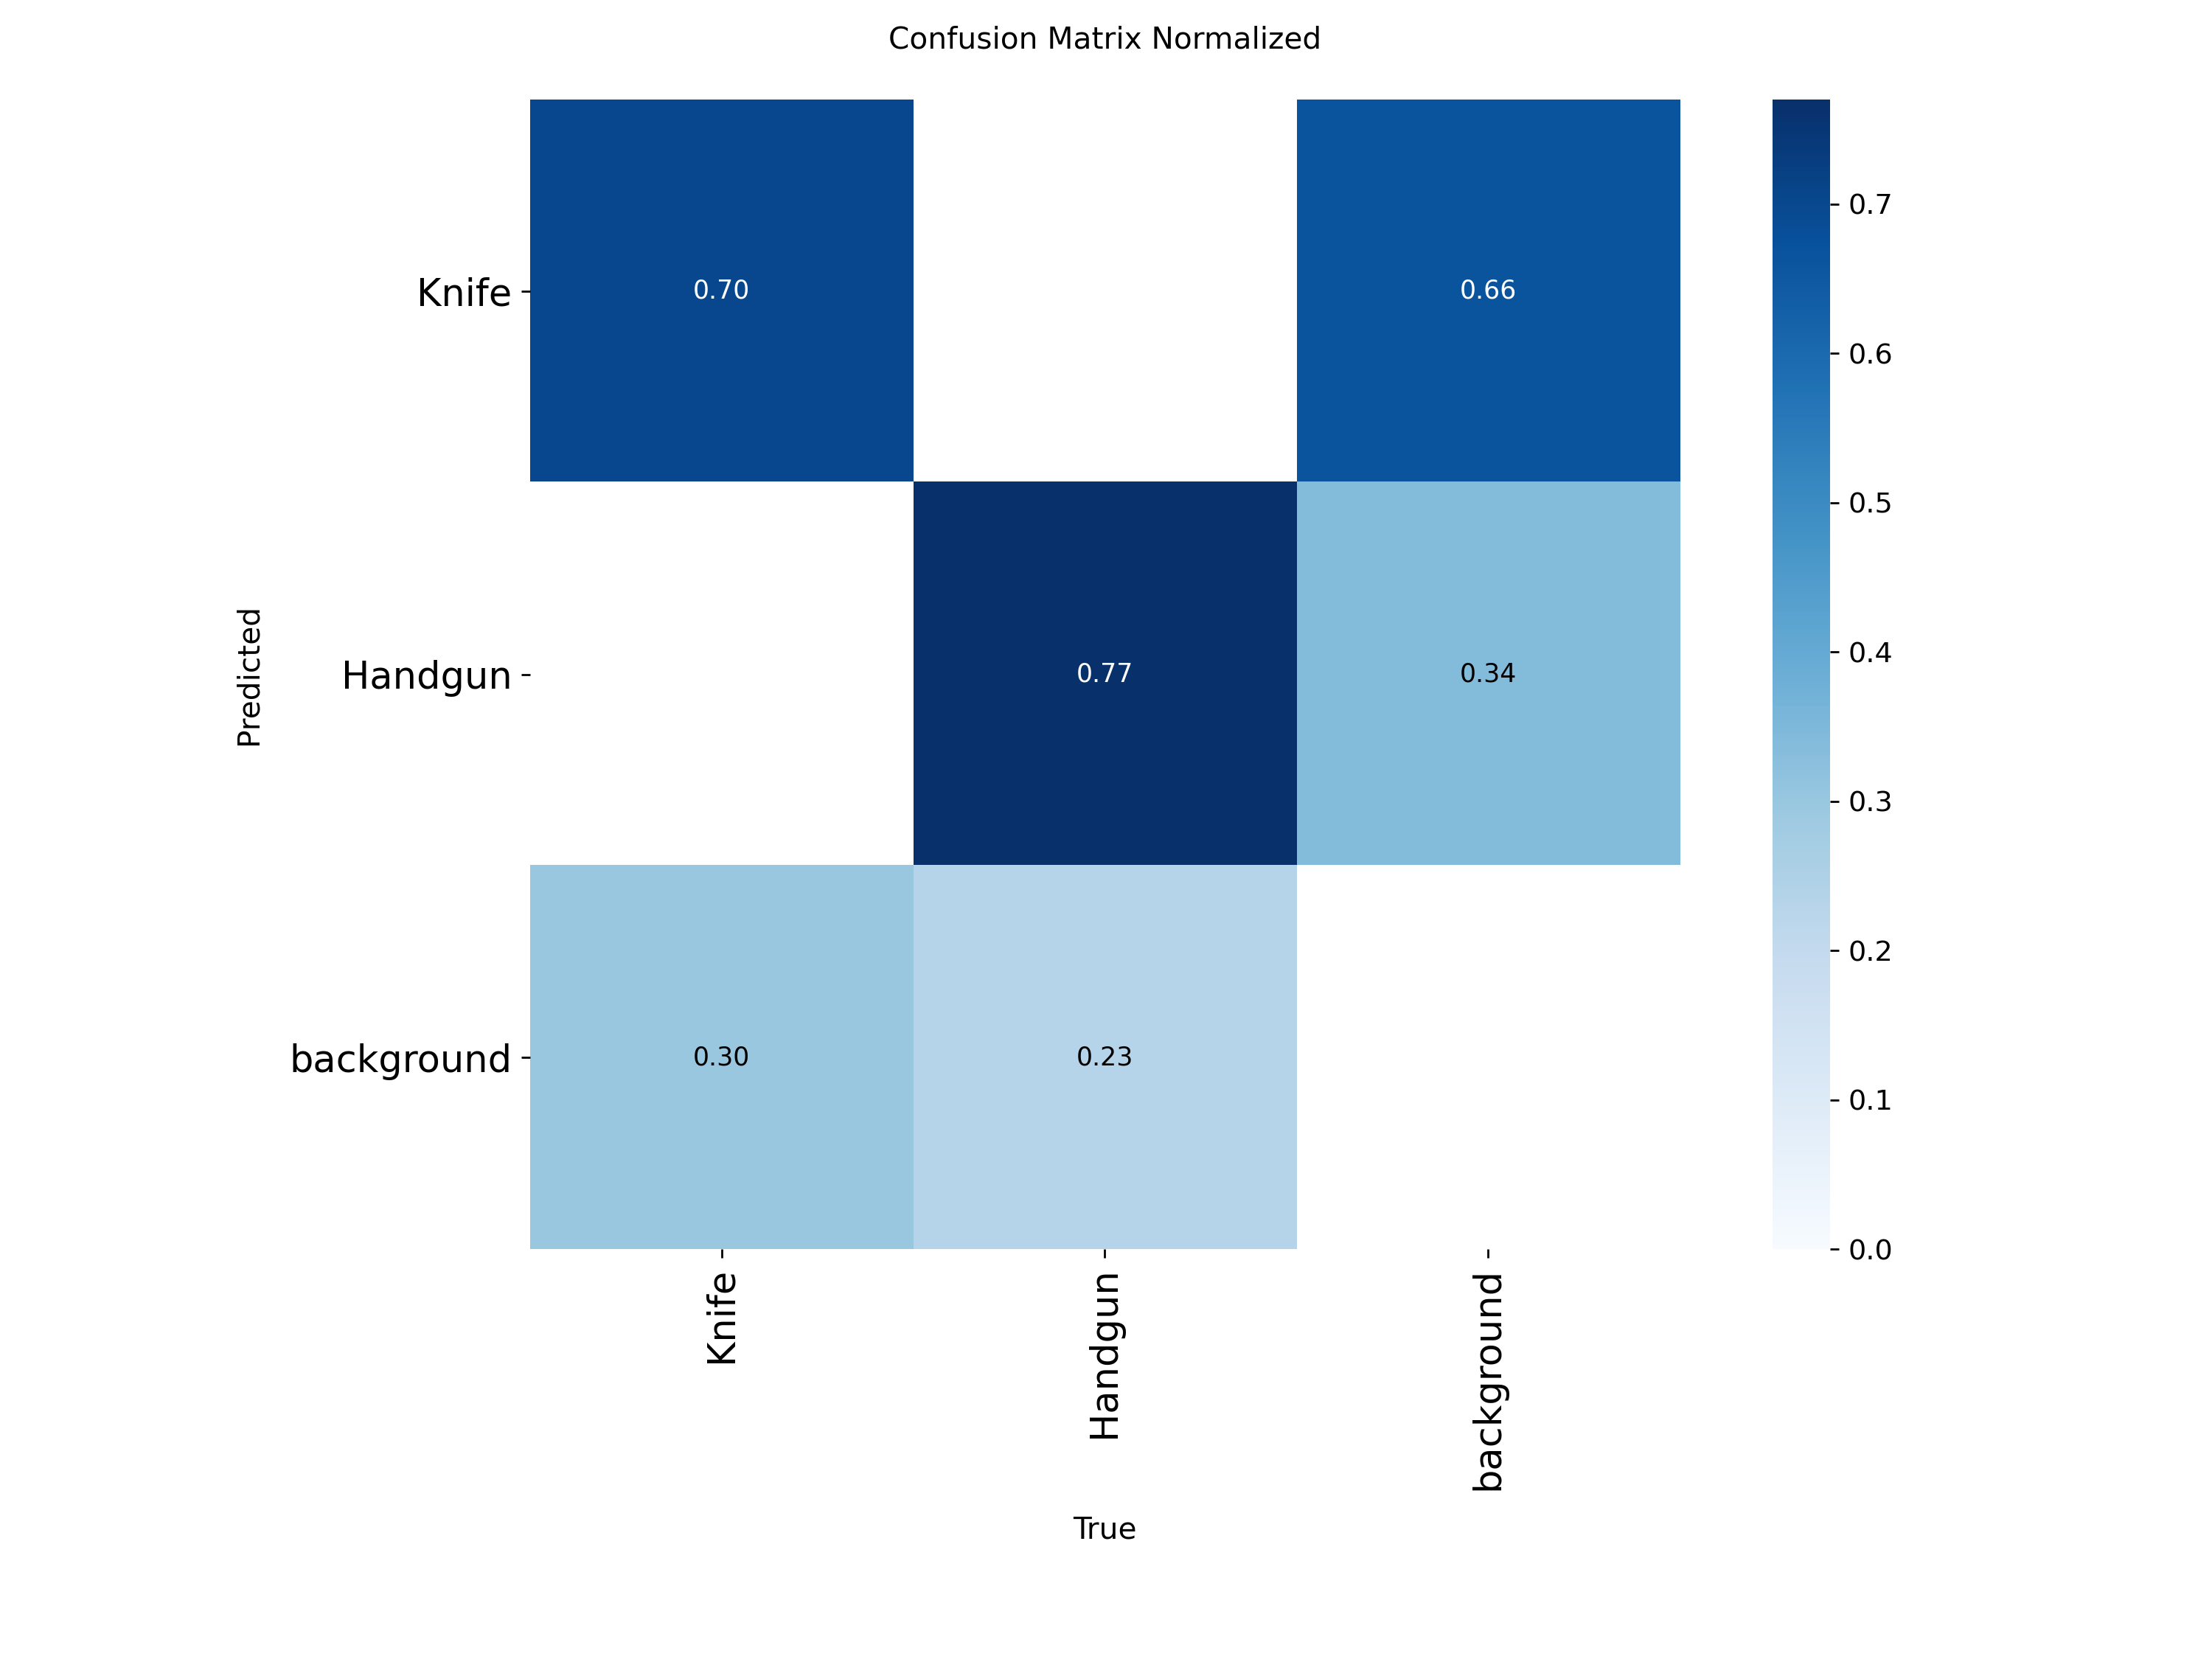

F1_curve.png not found
P_curve.png not found
R_curve.png not found
PR_curve.png not found


In [2]:
import os
from IPython.display import Image, display

val_dir = "/kaggle/working/runs/detect/val"

print("Files in validation folder:")
print(os.listdir(val_dir))

images_to_show = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "PR_curve.png"
]

for img_name in images_to_show:
    img_path = os.path.join(val_dir, img_name)
    if os.path.exists(img_path):
        print(f"\nShowing: {img_name}")
        display(Image(filename=img_path))
    else:
        print(f"{img_name} not found")

In [3]:
import os

external_root = "/kaggle/input/external-weapons"

if not os.path.exists(external_root):
    # fallback: poore input mein external_weapons naam dhoondo
    for root, dirs, files in os.walk("/kaggle/input"):
        if "external" in root.lower():
            print("Possible folder:", root)
            if files:
                print("Files:", files)
                print("-" * 60)
else:
    print("External dataset folder found:", external_root)
    for root, dirs, files in os.walk(external_root):
        if files:
            print(root)
            print(files)
            print("-" * 60)

Possible folder: /kaggle/input/datasets/sibtainabbas1965/external-weapons
Files: ['images (2).jpg', '344f9ecad9d7d744374299101083b92f8694a1c9.jpg', 'images (1).jpg', 'YTDown.com_Shorts_You-SHOULD-bring-a-knife-to-a-gunfight-f_Media_8lxvdMdKrG0_003_480p.mp4', 'images.jpg']
------------------------------------------------------------



=== External Image 1 ===
Input: /kaggle/input/datasets/sibtainabbas1965/external-weapons/images.jpg
Results saved to /kaggle/working/runs/detect/predict
Saved output: /kaggle/working/runs/detect/predict/images.jpg


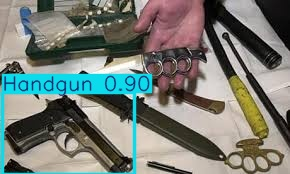


=== External Image 2 ===
Input: /kaggle/input/datasets/sibtainabbas1965/external-weapons/images (1).jpg
Results saved to /kaggle/working/runs/detect/predict
Saved output: /kaggle/working/runs/detect/predict/images (1).jpg


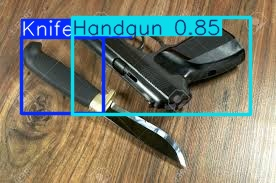


=== External Image 3 ===
Input: /kaggle/input/datasets/sibtainabbas1965/external-weapons/images (2).jpg
Results saved to /kaggle/working/runs/detect/predict
Saved output: /kaggle/working/runs/detect/predict/images (2).jpg


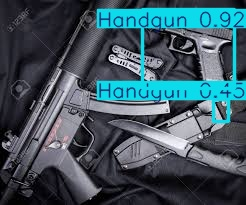


=== External Image 4 ===
Input: /kaggle/input/datasets/sibtainabbas1965/external-weapons/344f9ecad9d7d744374299101083b92f8694a1c9.jpg
Results saved to /kaggle/working/runs/detect/predict
Saved output: /kaggle/working/runs/detect/predict/344f9ecad9d7d744374299101083b92f8694a1c9.jpg


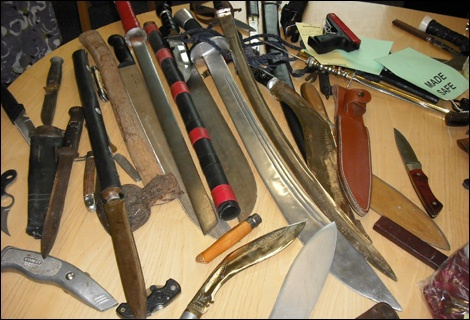

In [4]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

# saved trained model
best_model_path = "/kaggle/input/notebooks/sibtainabbas1965/notebookaca5840b38/weapon_detection_yolov8s/weights/best.pt"

# external images
external_images = [
    "/kaggle/input/datasets/sibtainabbas1965/external-weapons/images.jpg",
    "/kaggle/input/datasets/sibtainabbas1965/external-weapons/images (1).jpg",
    "/kaggle/input/datasets/sibtainabbas1965/external-weapons/images (2).jpg",
    "/kaggle/input/datasets/sibtainabbas1965/external-weapons/344f9ecad9d7d744374299101083b92f8694a1c9.jpg",
]

model = YOLO(best_model_path)

for i, img_path in enumerate(external_images, 1):
    print(f"\n=== External Image {i} ===")
    print("Input:", img_path)

    results = model.predict(
        source=img_path,
        conf=0.30,
        save=True,
        verbose=False
    )

    save_dir = results[0].save_dir
    output_image = os.path.join(save_dir, os.path.basename(img_path))

    print("Saved output:", output_image)
    display(Image(filename=output_image))

In [5]:
from ultralytics import YOLO
from IPython.display import Video, display
import os

best_model_path = "/kaggle/input/notebooks/sibtainabbas1965/notebookaca5840b38/weapon_detection_yolov8s/weights/best.pt"
video_path = "/kaggle/input/datasets/sibtainabbas1965/external-weapons/YTDown.com_Shorts_You-SHOULD-bring-a-knife-to-a-gunfight-f_Media_8lxvdMdKrG0_003_480p.mp4"

model = YOLO(best_model_path)

results = model.predict(
    source=video_path,
    conf=0.30,
    save=True,
    verbose=False
)

save_dir = results[0].save_dir
print("Prediction folder:", save_dir)
print("Files in folder:", os.listdir(save_dir))

output_video = os.path.join(save_dir, os.path.basename(video_path))
print("Output video:", output_video)

display(Video(output_video, embed=True))

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /kaggle/working/runs/detect/predict2
Prediction folder: /kaggle/working/runs/detect/predict2
Files in folder: ['YTDown.com_Shorts_You-SHOULD-bring-a-knife-to-a-gunfight-f_Media_8lxvdMdKrG0_003_480p.avi']
Output video: /kaggle/working/runs/detect/predict2/YTDown.com_Shorts_You-SHOULD-bring-a-knife-to-a-gunfight-f_Media_8lxvdMdKrG0_003_480p.mp4


In [6]:
import shutil
import os

src = "/kaggle/input/notebooks/sibtainabbas1965/notebookaca5840b38/weapon_detection_yolov8s/weights/best.pt"
dst = "/kaggle/working/best.pt"

shutil.copy(src, dst)

print("Copied:", os.path.exists(dst))
print("New file:", dst)

Copied: True
New file: /kaggle/working/best.pt
